# Problem Statements: -

# 1.	Business Problem

In [9]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 

In [10]:
df=pd.read_csv("Startups.csv")

In [11]:
df.sample(5)

,R&D Spend,Administration,Marketing Spend,State,Profit
9,123334.88,108679.17,304981.62,California,149759.96
34,46426.07,157693.92,210797.67,California,96712.80
22,73994.56,122782.75,303319.26,Florida,110352.25
8,120542.52,148718.95,311613.29,New York,152211.77
19,86419.70,153514.11,0.00,New York,122776.86


In [6]:
df.shape

(50, 5)

In [8]:
df.isnull().mean()*100

R&D Spend          0.0
Administration     0.0
Marketing Spend    0.0
State              0.0
Profit             0.0
dtype: float64

In [12]:
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [13]:
set(df['State'])

{'California', 'Florida', 'New York'}

In [27]:
num1=['R&D Spend','Administration','Profit','Marketing Spend']
cat=['State']

In [28]:
num=pd.DataFrame()
for i in num1: 
    num[i]=df[i]

In [30]:
num.describe()

,R&D Spend,Administration,Profit,Marketing Spend
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,112012.639200,211025.097800
std,45902.256482,28017.802755,40306.180338,122290.310726
min,0.000000,51283.140000,14681.400000,0.000000
25%,39936.370000,103730.875000,90138.902500,129300.132500
50%,73051.080000,122699.795000,107978.190000,212716.240000
75%,101602.800000,144842.180000,139765.977500,299469.085000
max,165349.200000,182645.560000,192261.830000,471784.100000


In [31]:
num.isnull().sum()

R&D Spend          0
Administration     0
Profit             0
Marketing Spend    0
dtype: int64

In [32]:
num.skew()

R&D Spend          0.164002
Administration    -0.489025
Profit             0.023291
Marketing Spend   -0.046472
dtype: float64

In [33]:
num.kurtosis()

R&D Spend         -0.761465
Administration     0.225071
Profit            -0.063859
Marketing Spend   -0.671701
dtype: float64

In [34]:
num.corr()

,R&D Spend,Administration,Profit,Marketing Spend
R&D Spend,1.000000,0.241955,0.972900,0.724248
Administration,0.241955,1.000000,0.200717,-0.032154
Profit,0.972900,0.200717,1.000000,0.747766
Marketing Spend,0.724248,-0.032154,0.747766,1.000000


# EDA

<Axes: xlabel='R&D Spend', ylabel='Density'>

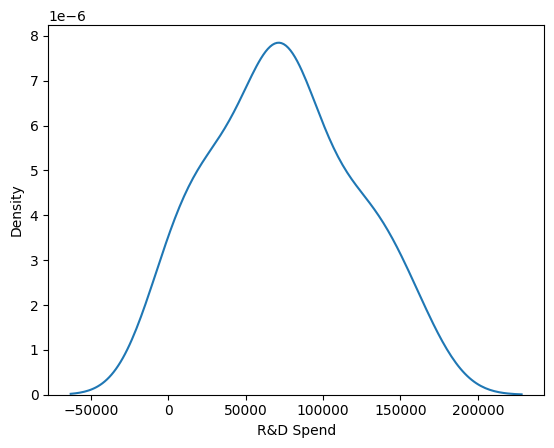

In [35]:
# numerical coiums 
sns.kdeplot(df['R&D Spend'])

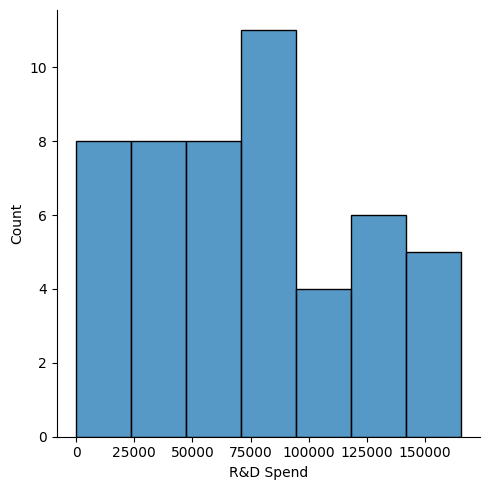

In [36]:
sns.displot(df['R&D Spend'])

<Axes: ylabel='R&D Spend'>

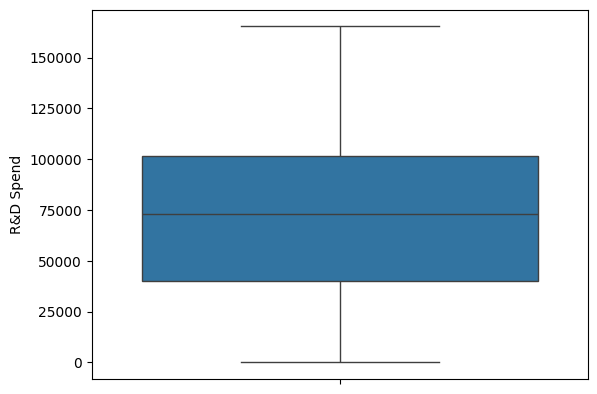

In [37]:
sns.boxplot(df['R&D Spend'])

<Axes: xlabel='Administration', ylabel='Density'>

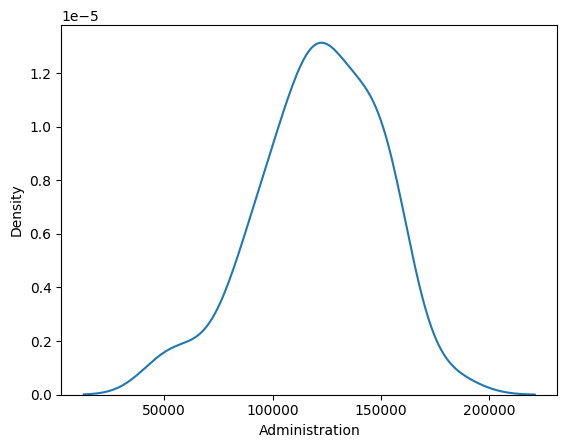

In [38]:
sns.kdeplot(df['Administration'])

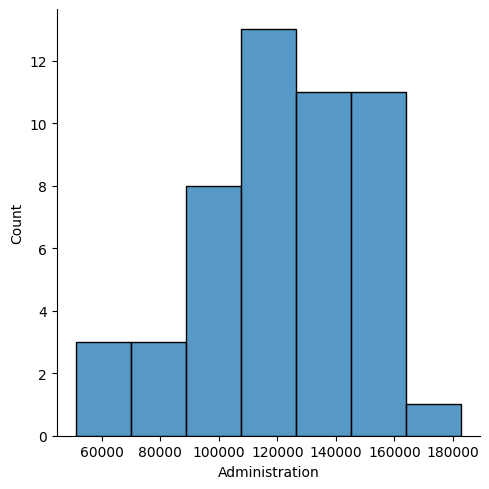

In [39]:
sns.displot(df['Administration'])

<Axes: ylabel='Administration'>

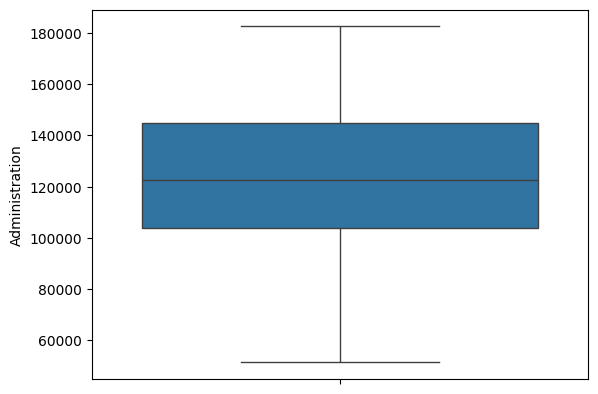

In [40]:
sns.boxplot(df['Administration'])

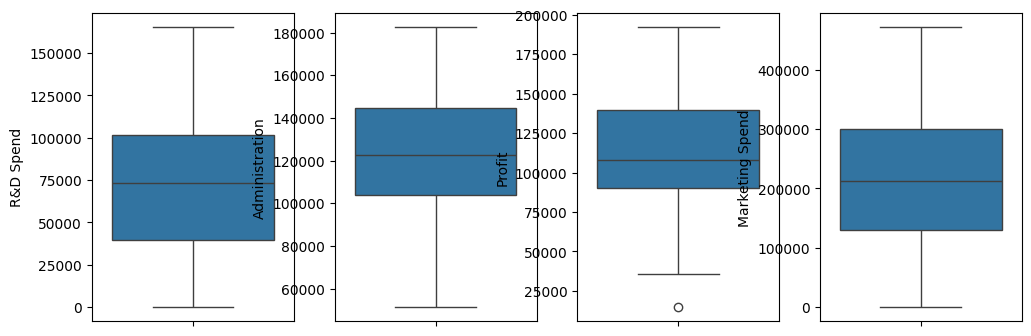

In [42]:
ax=plt.figure(figsize=(12,4))
for i in range(len(num1)): 
    plt.subplot(1,4,i+1)    
    sns.boxplot(df[num1[i]])    

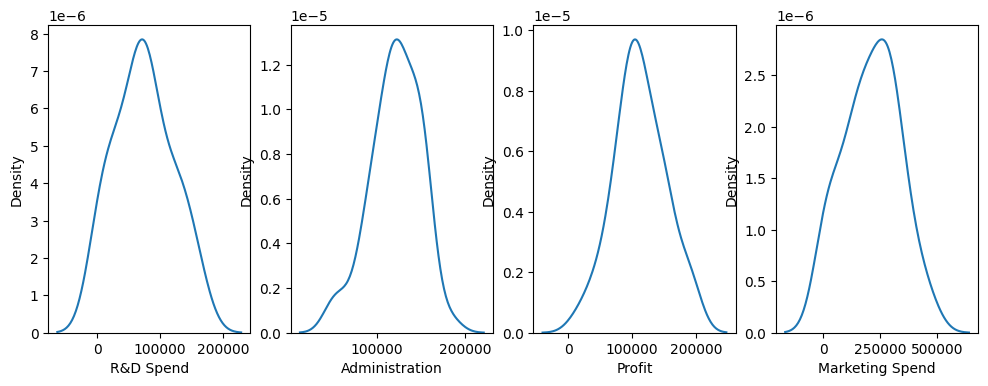

In [43]:
ax=plt.figure(figsize=(12,4))
for i in range(len(num1)): 
    plt.subplot(1,4,i+1)    
    sns.kdeplot(df[num1[i]])    

<Axes: >

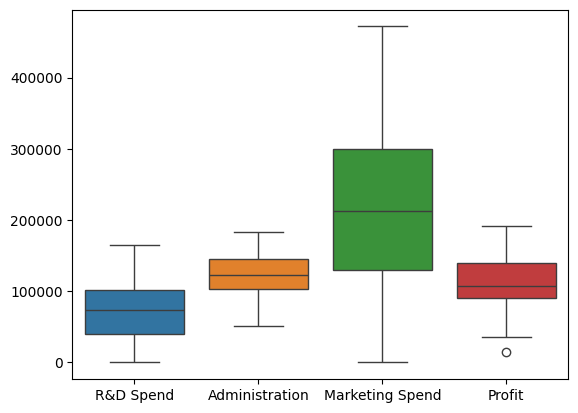

In [48]:
sns.boxplot(df)

In [51]:
num.corr()

,R&D Spend,Administration,Profit,Marketing Spend
R&D Spend,1.000000,0.241955,0.972900,0.724248
Administration,0.241955,1.000000,0.200717,-0.032154
Profit,0.972900,0.200717,1.000000,0.747766
Marketing Spend,0.724248,-0.032154,0.747766,1.000000


<Axes: >

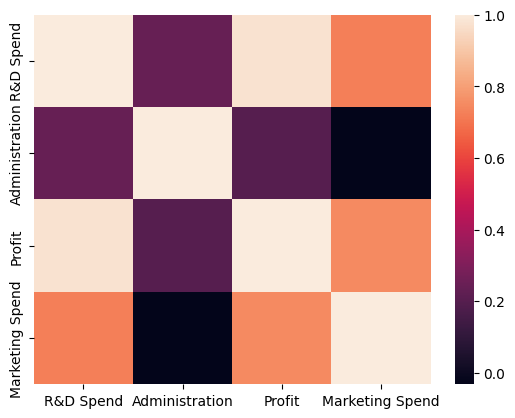

In [52]:
sns.heatmap(num.corr())

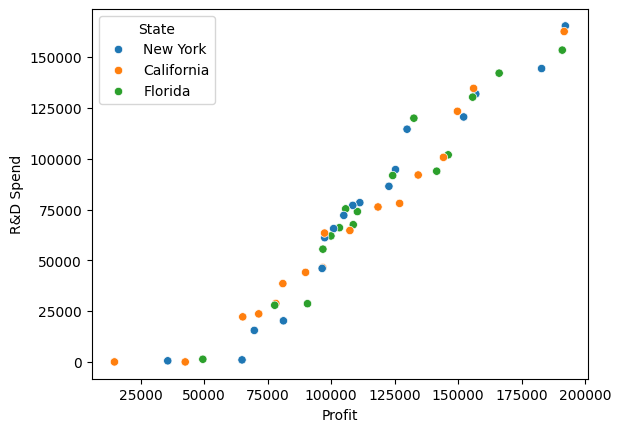

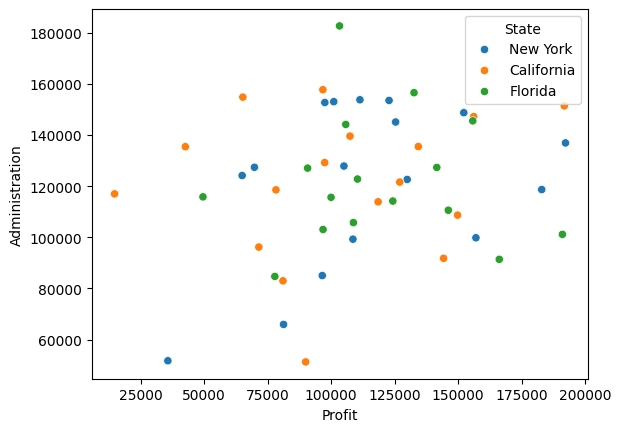

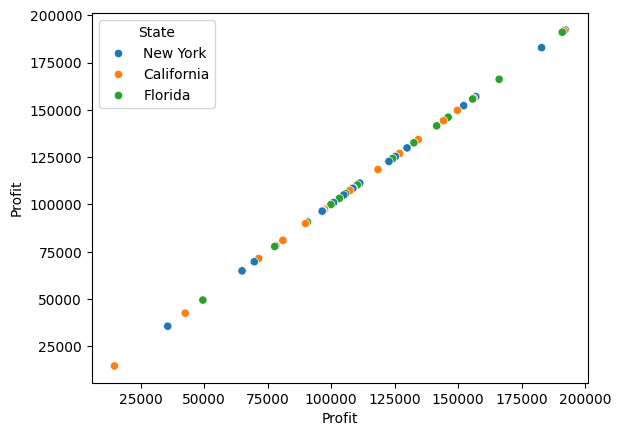

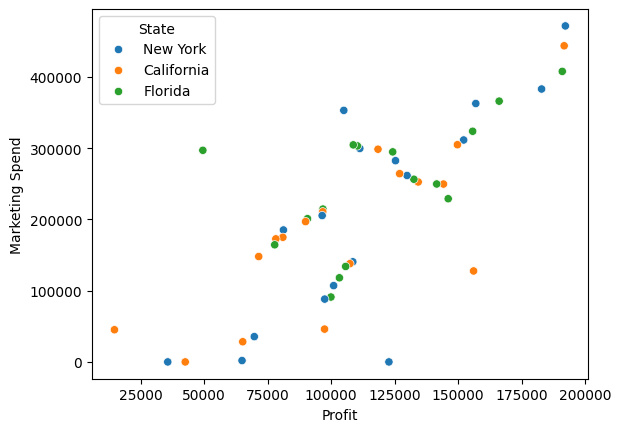

In [55]:
for i in num: 
    sns.scatterplot(df,x='Profit',y=i,hue='State')
    plt.show()

<Axes: ylabel='count'>

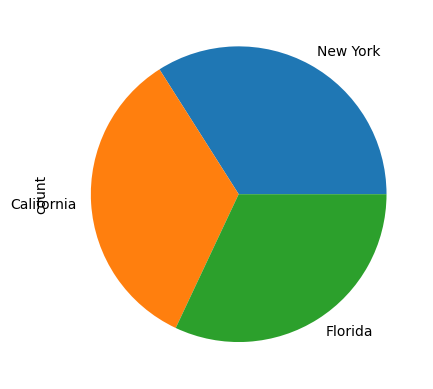

In [57]:
df['State'].value_counts().plot(kind='pie')

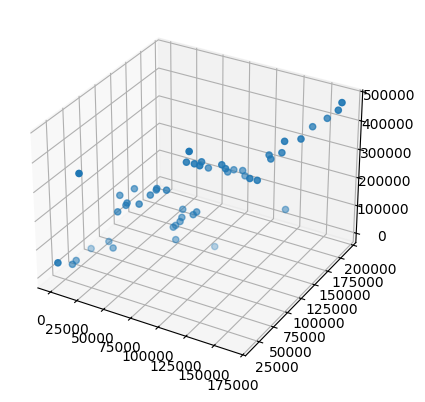

In [61]:
ax =plt.subplot(projection='3d')
ax.scatter(df['R&D Spend'],df['Profit'],df['Marketing Spend'])

In [62]:
from matplotlib.pyplot import scatter
from plotly.express import scatter_3d

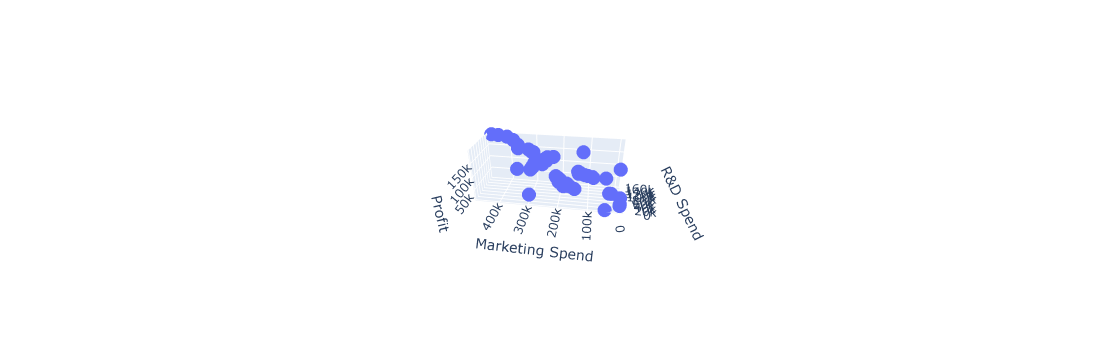

In [64]:
scatter_3d(df,x='R&D Spend',y='Marketing Spend',z='Profit')

# Data Preprocessing

In [65]:
# one hot incode 
# scling of data 

In [68]:
num1.remove('Profit')

In [69]:
num1

['R&D Spend', 'Administration', 'Marketing Spend']

In [70]:
from sklearn.preprocessing import MinMaxScaler 
scaler =MinMaxScaler()
X=pd.DataFrame()

In [75]:
for i in num1 : 
    X[i]=pd.DataFrame(scaler.fit_transform(df[[i]]))

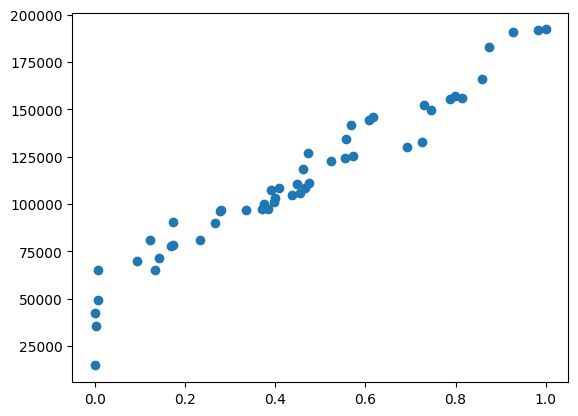

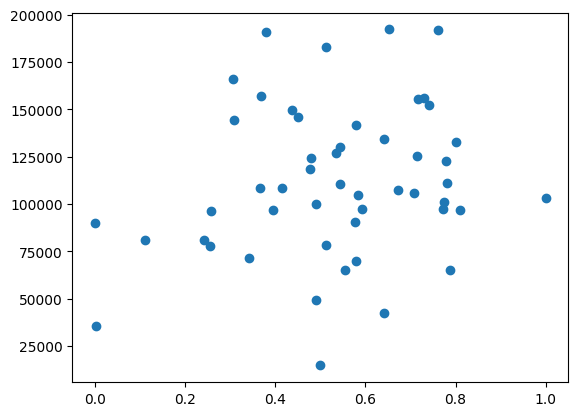

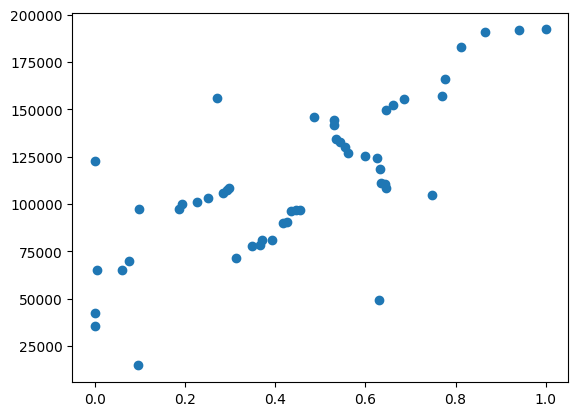

In [80]:
for i in num1: 
    plt.scatter(X[i],df['Profit'])
    plt.show()

In [81]:
X['State']=df['State']

In [84]:
X=pd.get_dummies(X,columns=['State'],dtype=int)

In [87]:
y=df['Profit']

# spliting Data 



In [88]:
from sklearn.model_selection import train_test_split 
X_train,X_test,y_train,y_test =train_test_split(X,y,test_size=0.2,random_state=42)

# Model making

In [90]:
from sklearn.linear_model import LinearRegression 
from sklearn.tree import DecisionTreeRegressor 
from sklearn.ensemble import RandomForestRegressor 
from xgboost.sklearn import XGBRegressor 
from sklearn.metrics import r2_score,roc_auc_score,root_mean_squared_error

<h2> Simple regression

In [91]:
reg=LinearRegression()
reg.fit(X_train,y_train)

LinearRegression()

In [92]:
y_pred1=reg.predict(X_test)
r2_score(y_test,y_pred1)

0.898726641431984

<h2> Polynomial regression

In [93]:
from sklearn.preprocessing import PolynomialFeatures
pol=PolynomialFeatures(degree=2)
X_train_trf=pol.fit_transform(X_train)
X_test_trf = pol.transform(X_test)

In [94]:
reg1=LinearRegression()
reg1.fit(X_train_trf,y_train)

LinearRegression()

In [96]:
y_pred2=reg1.predict(X_test_trf)
r2_score(y_test,y_pred2)

0.9004715914970879

<h2> RandomForestRegressor

In [138]:
reg3=RandomForestRegressor(n_estimators=300,max_depth=20,max_features=20)
reg3.fit(X_train,y_train)

RandomForestRegressor(max_depth=20, max_features=20, n_estimators=300)

In [139]:
y_pred3=reg3.predict(X_test)
r2_score(y_test,y_pred3)

0.9185222484863946

# Xgboost

In [114]:
reg4 = XGBRegressor(n_estimators=200)
reg4.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=200, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [115]:
y_pred4=reg4.predict(X_test)
r2_score(y_test,y_pred4) 

0.8854450938470685